# 1. Business Understanding

## Business Problem

Airlines collect a large amount of information about their passengers' travel experiences, including customer characteristics, travel details, service ratings, and flight delays. However, it is important for the airline to understand which of these factors have the greatest influence on overall passenger satisfaction.

Low passenger satisfaction can affect customer loyalty, repeat bookings, and the airline's reputation. Therefore, understanding the main drivers of satisfaction can help the airline identify areas where service improvements will have the greatest impact.

## Business Objective

The objective of this project is to analyze airline passenger data to understand the factors that influence passenger satisfaction and provide actionable recommendations that can help improve the overall passenger experience.

Specifically, this project aims to:

- Identify the factors most strongly associated with passenger satisfaction.
- Compare satisfaction levels across different passenger groups, travel types, and classes.
- Investigate whether flight delays are associated with passenger satisfaction.
- Determine which airline services have the greatest influence on satisfaction.
- Develop a machine learning model that can predict whether a passenger is satisfied or dissatisfied.

## Data Science Objective

This is a **binary classification problem** where the target variable is:

`satisfaction`

The model will use passenger demographic information, travel characteristics, service ratings, and delay information to predict passenger satisfaction.

## Key Business Question

> **What factors most strongly influence airline passenger satisfaction, and how can the airline use these insights to improve the passenger experience?**

# 2. Data Understanding
### 2.1 Describing data

The purpose of this phase is to become familiar with the dataset and assess its quality before performing any data preparation or modeling.

We will:

- Load the airline passenger satisfaction dataset.
- Examine the number of rows and columns.
- Inspect the data types of the variables.
- Identify missing values.
- Check for duplicate records.
- Examine the distribution of the target variable, `satisfaction`.
- Explore the values and distributions of important categorical and numerical variables.

Understanding the structure and quality of the data will help us determine what cleaning and preparation steps are required before modeling.

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Users\user\OneDrive\Projects\Airline Passenger Satisfaction\Airplane_passenger_satisfaction.csv")

In [5]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [6]:
df.tail()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied
25975,25975,34799,Female,Loyal Customer,42,Personal Travel,Eco,264,2,5,...,1,1,2,1,1,1,1,0,0.0,neutral or dissatisfied


In [7]:
df.shape

(25976, 25)

In [8]:
df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [9]:
df.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25976.0,12987.500000,7498.769632,0.0,6493.75,12987.5,19481.25,25975.0
id,25976.0,65005.657992,37611.526647,17.0,32170.50,65319.5,97584.25,129877.0
Age,25976.0,39.620958,15.135685,7.0,27.00,40.0,51.00,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.00,849.0,1744.00,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.00,3.0,4.00,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.00,3.0,4.00,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.00,3.0,4.00,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.00,4.0,4.00,5.0


In [12]:
df.isnull().sum()

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [13]:
df.duplicated().any()

False

In [14]:
df.duplicated().sum()

0

In [15]:
df['satisfaction'].value_counts()

satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64

**understand what categories actually exist in each variable**

In [16]:
categorical_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

for column in categorical_columns:
    print(f"\n")
    print(df[column].value_counts())



Gender
Female    13172
Male      12804
Name: count, dtype: int64


Customer Type
Loyal Customer       21177
disloyal Customer     4799
Name: count, dtype: int64


Type of Travel
Business travel    18038
Personal Travel     7938
Name: count, dtype: int64


Class
Business    12495
Eco         11564
Eco Plus     1917
Name: count, dtype: int64


In [17]:
df.isnull().sum()

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


### 2.2 Exploratory Data Analysis

>Exploratory Data Analysis (EDA) is used to understand patterns, distributions, relationships, and potential anomalies in the dataset.

>We begin by examining the distribution of the target variable, `satisfaction`. Understanding the target variable is important because it is the outcome we want to explain and eventually predict.|

### 2.21 **Business question 1:What is the overall level of passenger satisfaction?**

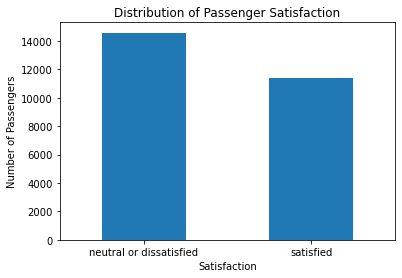

In [18]:
import matplotlib.pyplot as plt

df["satisfaction"].value_counts().plot(kind="bar")

plt.title("Distribution of Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

### Key Observations

- The dataset contains more passengers who are **neutral or dissatisfied** than passengers who are **satisfied**.
- Approximately **56.1%** of passengers are neutral or dissatisfied, while approximately **43.9%** are satisfied.
- The two classes are reasonably represented in the dataset, although the target variable is not perfectly balanced.
- Therefore, there is sufficient representation of both satisfaction categories for further analysis and classification modeling.

### 2.22 **Business question 2:How does satisfaction levels differ across genders?**
>We will compare passenger satisfaction between male and female passengers to determine whether satisfaction levels differ by gender.

>This analysis will help us understand whether gender is associated with passenger satisfaction and whether there are noticeable differences between the two passenger groups.

In [19]:
pd.crosstab(df["Gender"], df["satisfaction"])


satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,7437,5735
Male,7136,5668


In [20]:
gender_satisfaction = pd.crosstab(df["Gender"],df["satisfaction"],normalize="index")  * 100
gender_satisfaction



satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,56.460674,43.539326
Male,55.732584,44.267416


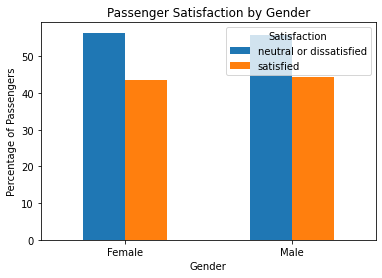

In [21]:
gender_satisfaction.plot(kind="bar")

plt.title("Passenger Satisfaction by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.show()


### **Key observations**
> The satisfaction levels by both genders(male and female) is almost balanced with the neutral and dissatisfied levels of female being around **56.460674%** and for male being **55.732584%**. The satisfaction levels for female is **43.539326%** and that of men being **44.267416%**. This means that **Gender is not a main differentiating factor in our dataset**

### 2.2.3 **Business question : How does satisfaction levels differ across customer types?**
##### **customer types**
>1. loyal customer

>2. disloyal customer

In [22]:
pd.crosstab(df["satisfaction"], df["Customer Type"])

Customer Type,Loyal Customer,disloyal Customer
satisfaction,,
neutral or dissatisfied,10982,3591
satisfied,10195,1208


In [23]:
customer_satisfaction = pd.crosstab(df["Customer Type"], df["satisfaction"], normalize = "index") * 100
customer_satisfaction

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,51.858148,48.141852
disloyal Customer,74.828089,25.171911


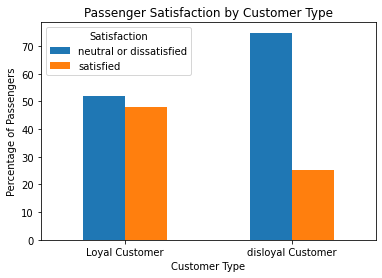

In [24]:
customer_satisfaction.plot(kind="bar")

plt.title("Passenger Satisfaction by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.show()

### Key Observations

- Among loyal customers, approximately **48.14%** are satisfied, while **51.86%** are neutral or dissatisfied.
- Among disloyal customers, approximately **25.17%** are satisfied, while **74.83%** are neutral or dissatisfied.
- The satisfaction rate is therefore much higher among loyal customers than among disloyal customers.
- There is approximately a **22.97 percentage-point difference** in satisfaction between the two customer types.
- This difference is much larger than the difference observed between male and female passengers.
- This suggests that **customer type is more strongly associated with passenger satisfaction than gender** in this dataset.
- However, this analysis shows an association and does not establish that customer type causes passenger satisfaction.

### Business Interpretation

The results suggest that disloyal customers have considerably lower satisfaction levels than loyal customers. This may indicate an opportunity for the airline to focus on improving the passenger experience for customers who are less likely to remain loyal.

The airline could investigate which service areas are contributing most to dissatisfaction among disloyal customers. This will be explored further when we analyze individual service ratings.

### 2.2.4 Business Question: Does Satisfaction Differ by Type of Travel?

>Type of Travel indicates whether a passenger is travelling for business or personal reasons.

>This analysis compares satisfaction levels between business and personal travellers to determine whether type of travel is associated with passenger satisfaction.

>Understanding this difference can help the airline identify whether the needs and expectations of business travellers differ from those of passengers travelling for personal reasons.

In [25]:
pd.crosstab(df["Type of Travel"], df["satisfaction"])

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,7428,10610
Personal Travel,7145,793


In [26]:
travel_satisfaction = pd.crosstab(df["Type of Travel"], df["satisfaction"], normalize = "index") * 100
travel_satisfaction

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.179732,58.820268
Personal Travel,90.010078,9.989922


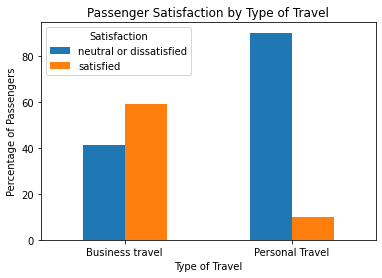

In [27]:
travel_satisfaction.plot(kind="bar")

plt.title("Passenger Satisfaction by Type of Travel")
plt.xlabel("Type of Travel")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.show()

### Key Observations

- Among business travellers, **58.82%** are satisfied, while **41.18%** are neutral or dissatisfied.
- Among personal travellers, only **9.99%** are satisfied, while **90.01%** are neutral or dissatisfied.
- Business travellers therefore have a much higher satisfaction rate than personal travellers.
- The difference in satisfaction between the two travel types is approximately **48.83 percentage points**.
- This is a much larger difference than the differences observed for gender and customer type.
- This suggests that **Type of Travel is strongly associated with passenger satisfaction** in this dataset.
- However, this analysis shows an association and does not establish that type of travel causes passenger satisfaction.

### Business Interpretation

>The results show a substantial difference in satisfaction between business and personal travellers. Business travellers are considerably more likely to report being satisfied, while personal travellers have a much higher proportion of neutral or dissatisfied passengers.

>This suggests that the airline may need to investigate whether the services, pricing, convenience, or overall experience provided to personal travellers meet their expectations.

>Further analysis of individual service ratings will help us identify which aspects of the passenger experience may be associated with this difference in satisfaction.

### 2.2.5 Business Question: Does Satisfaction Differ Across Travel Classes?

The Class variable identifies the travel class of each passenger: Business, Eco, or Eco Plus.

This analysis compares passenger satisfaction across the different travel classes to determine whether travel class is associated with passenger satisfaction.

Understanding satisfaction across travel classes can help the airline identify whether passengers in different classes have different levels of satisfaction and whether certain classes may require greater attention.

In [28]:
pd.crosstab(df["Class"], df["satisfaction"])

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,3809,8686
Eco,9322,2242
Eco Plus,1442,475


In [29]:
class_satisfaction = pd.crosstab(df["Class"], df["satisfaction"], normalize = "index") * 100
class_satisfaction

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.484194,69.515806
Eco,80.612245,19.387755
Eco Plus,75.221701,24.778299


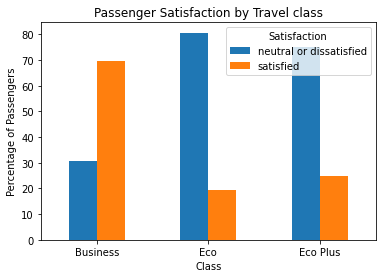

In [30]:
class_satisfaction.plot(kind="bar")

plt.title("Passenger Satisfaction by Travel class")
plt.xlabel("Class")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.show()

### Key Observations

- Among Business class passengers, **69.52%** are satisfied, while **30.48%** are neutral or dissatisfied.
- Among Eco passengers, only **19.39%** are satisfied, while **80.61%** are neutral or dissatisfied.
- Among Eco Plus passengers, **24.78%** are satisfied, while **75.22%** are neutral or dissatisfied.
- Business class has the highest satisfaction rate, while Eco has the lowest.
- The difference in satisfaction between Business and Eco passengers is approximately **50.13 percentage points**.
- Eco Plus passengers have a slightly higher satisfaction rate than Eco passengers, but satisfaction remains substantially lower than in Business class.
- This suggests that **travel class is strongly associated with passenger satisfaction** in this dataset.
- However, this analysis shows an association and does not establish that travel class causes passenger satisfaction.

### Business Interpretation

>The results show substantial differences in passenger satisfaction across travel classes. Business class passengers have considerably higher satisfaction levels than both Eco and Eco Plus passengers.

>The relatively low satisfaction among Eco and Eco Plus passengers suggests that the airline should investigate which aspects of the passenger experience may be contributing to dissatisfaction in these classes.

>Further analysis of individual service ratings will help identify the specific areas that may be associated with the differences in satisfaction across travel classes.

### 2.2.6 Business Question: Which Individual Airline Services Are Most Strongly Associated with Passenger Satisfaction?

The dataset contains several passenger ratings for different airline services.

This analysis will investigate whether higher service ratings are associated with higher passenger satisfaction.

Rather than looking at each service separately, we will compare the average rating for satisfied passengers with the average rating for neutral or dissatisfied passengers.

This will help us identify which service areas show the largest differences between the two satisfaction groups and may therefore be important areas for further investigation.

In [31]:
service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

In [32]:
service_satisfaction = df.groupby("satisfaction")[service_columns].mean().T
service_satisfaction
 

satisfaction,neutral or dissatisfied,satisfied
Inflight wifi service,2.393536,3.148031
Departure/Arrival time convenient,3.134701,2.934491
Ease of Online booking,2.559665,3.008682
Gate location,2.995951,2.952995
Food and drink,2.959926,3.541787
Online boarding,2.668702,4.019469
Seat comfort,3.044878,3.965974
Inflight entertainment,2.885473,3.961326
On-board service,3.021066,3.851618
Leg room service,2.988952,3.811804


In [33]:
service_satisfaction["difference"] = (
    service_satisfaction["satisfied"]
    - service_satisfaction["neutral or dissatisfied"]
)

service_satisfaction.sort_values(
    "difference",
    ascending=False
)

satisfaction,neutral or dissatisfied,satisfied,difference
Online boarding,2.668702,4.019469,1.350766
Inflight entertainment,2.885473,3.961326,1.075853
Seat comfort,3.044878,3.965974,0.921096
Cleanliness,2.919371,3.755064,0.835693
On-board service,3.021066,3.851618,0.830552
Leg room service,2.988952,3.811804,0.822852
Inflight wifi service,2.393536,3.148031,0.754495
Checkin service,3.043025,3.660703,0.617679
Baggage handling,3.370548,3.968956,0.598407
Inflight service,3.392781,3.977024,0.584242


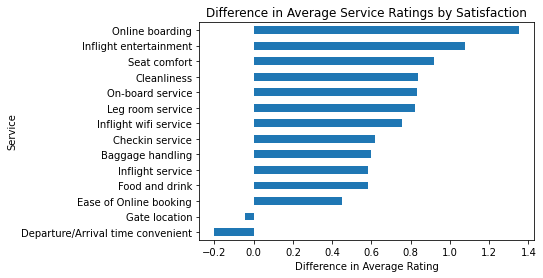

In [34]:
service_satisfaction["difference"].sort_values().plot(kind="barh")

plt.title("Difference in Average Service Ratings by Satisfaction")
plt.xlabel("Difference in Average Rating")
plt.ylabel("Service")
plt.show()

### Key Observations

- **Online boarding** has the largest difference in average rating between satisfied and neutral/dissatisfied passengers, with a difference of approximately **1.35 points**.
- **Inflight entertainment** has the second-largest difference, at approximately **1.08 points**.
- **Seat comfort** has the third-largest difference, at approximately **0.92 points**.
- Other services with relatively large differences include **Cleanliness (0.84)**, **On-board service (0.83)**, and **Leg room service (0.82)**.
- **Inflight wifi service** also shows a noticeable difference of approximately **0.75 points**.
- **Ease of Online booking** shows a smaller difference of approximately **0.45 points**.
- **Gate location** and **Departure/Arrival time convenient** are the only services where the average rating is slightly higher among neutral/dissatisfied passengers than among satisfied passengers.
- Overall, **online boarding, inflight entertainment, and seat comfort** show the largest differences in average ratings between the two satisfaction groups.
- These results suggest that several service-related factors are strongly associated with passenger satisfaction, although they do not establish that these services directly cause satisfaction

### Business Interpretation

The analysis suggests that digital services and the overall onboard passenger experience may be important areas for the airline to investigate.

Online boarding shows the largest difference in average ratings between satisfied and neutral/dissatisfied passengers. This suggests that improving the online boarding experience may be an important area for further investigation.

Inflight entertainment and seat comfort also show relatively large differences, indicating that the onboard experience may be associated with passenger satisfaction.

The airline should therefore pay particular attention to these service areas when considering improvements. However, further statistical analysis and machine learning will be needed to determine which factors provide the strongest predictive value for passenger satisfaction.

### 2.2.7 Business Question: Are Flight Delays Associated with Passenger Satisfaction?

Flight delays can affect the overall passenger experience and may be associated with passenger satisfaction.

This analysis compares the average departure and arrival delays between satisfied and neutral or dissatisfied passengers.

The purpose is to determine whether passengers in the different satisfaction groups experienced noticeably different levels of delay.

In [35]:
delay_satisfaction = df.groupby("satisfaction")[
    ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
].mean()

delay_satisfaction

,Departure Delay in Minutes,Arrival Delay in Minutes
satisfaction,,
neutral or dissatisfied,16.015371,16.766933
satisfied,12.121635,12.150902


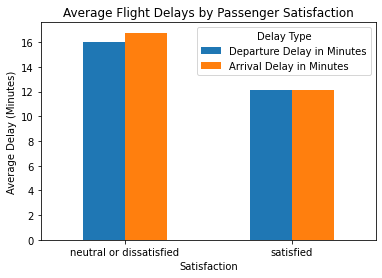

In [36]:
delay_satisfaction.plot(kind="bar")

plt.title("Average Flight Delays by Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=0)
plt.legend(title="Delay Type")
plt.show()

In [37]:
delay_median = df.groupby("satisfaction")[
    ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
].median()

delay_median

,Departure Delay in Minutes,Arrival Delay in Minutes
satisfaction,,
neutral or dissatisfied,0.0,0.0
satisfied,0.0,0.0


### Key Observations

- Neutral or dissatisfied passengers experienced a higher average departure delay (**16.02 minutes**) compared with satisfied passengers (**12.12 minutes**).
- Neutral or dissatisfied passengers also experienced a higher average arrival delay (**16.77 minutes**) compared with satisfied passengers (**12.15 minutes**).
- The average departure delay was approximately **3.89 minutes higher** among neutral or dissatisfied passengers.
- The average arrival delay was approximately **4.62 minutes higher** among neutral or dissatisfied passengers.
- However, the median departure and arrival delay was **0 minutes for both satisfaction groups**.
- This indicates that although a number of passengers experienced longer delays, at least half of passengers in each satisfaction group experienced no delay.
- The higher average delays among neutral or dissatisfied passengers suggest that **flight delays may be associated with lower passenger satisfaction**.
- However, the results do not establish that delays cause dissatisfaction, and the large difference between the mean and median suggests that extreme delays may be influencing the average.

### Business Interpretation

The analysis suggests that passengers who were neutral or dissatisfied experienced higher average flight delays than satisfied passengers.

However, the median delay for both groups is zero, indicating that delays were not experienced by the typical passenger. Instead, some passengers experienced substantially longer delays, which increased the average.

This suggests that reducing severe or unusually long delays may help improve the passenger experience. Further analysis will be useful to understand whether passengers experiencing longer delays are substantially more likely to be dissatisfied.

# 3. Data Preparation

Data preparation is the process of getting the dataset ready for analysis and machine learning.

In this stage, we will:

1. Remove unnecessary columns.
2. Check and handle missing values.
3. Check categorical variables.
4. Prepare the target variable.
5. Separate the features from the target.
6. Split the data into training and testing sets.
7. Prepare the data for machine-learning models.

The goal is to make sure the data is clean, consistent, and in a suitable format for modeling.

### 3.1 Remove Unnecessary Columns

The dataset contains two columns that are not useful for predicting passenger satisfaction:

- `Unnamed: 0` appears to be an automatically generated index.
- `id` is a passenger identifier.

These columns will be removed because they do not represent meaningful passenger, travel, service, or delay information.

In [38]:
df = df.drop(columns=["Unnamed: 0", "id"])

In [39]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


### Key Observations

The `Unnamed: 0` and `id` columns have been removed because they are identifiers rather than meaningful passenger or travel characteristics.

The remaining columns contain information that can potentially be used to understand and predict passenger satisfaction.

### Business Interpretation

Removing identifier columns helps ensure that the machine-learning models focus on meaningful passenger, travel, service, and delay information rather than arbitrary identification numbers.

### 3.2 Check Missing Values

Missing values can cause problems during machine learning because many algorithms cannot work directly with empty values.

We will check the dataset again to confirm which columns contain missing values before deciding how to handle them.

### Key Observations

The dataset contains missing values only in `Arrival Delay in Minutes`.

There are 83 missing values out of 25,976 passenger records, representing approximately 0.32% of the dataset.

The amount of missing data is very small, but it still needs to be handled before machine learning.

### Business Interpretation

Because only a very small proportion of arrival-delay values are missing, we can handle the missing values without losing a large number of passenger records.

We will avoid unnecessarily dropping these passengers and instead use an appropriate imputation method during the modeling preparation.

In [40]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)

df.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

### Why Use the Median?

We will use the median to replace the missing values in `Arrival Delay in Minutes`.

The delay data is right-skewed and contains some very large delay values. These extreme values can have a strong effect on the mean.

The median is less affected by extreme values, making it a more reliable measure for representing a typical delay in this dataset.

We also do not replace the missing values with 0 because a missing value does not necessarily mean that the passenger had no delay.

### 3.4 Checking Categorical Variables

Before building machine-learning models, we need to identify the categorical variables in the dataset.

Categorical variables contain labels or groups rather than continuous numerical values. Machine-learning models generally require these categories to be converted into numerical form.

We will first inspect the unique values in each categorical column before encoding them.

In [41]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

In [42]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())    #checks exact categories in each column


Gender:
['Female' 'Male']

Customer Type:
['Loyal Customer' 'disloyal Customer']

Type of Travel:
['Business travel' 'Personal Travel']

Class:
['Eco' 'Business' 'Eco Plus']

satisfaction:
['satisfied' 'neutral or dissatisfied']


### 3.5 Prepare the Target Variable

The `satisfaction` column is our target variable because it is the outcome we want the machine-learning model to predict.

Currently, the target contains two text categories:

- `satisfied`
- `neutral or dissatisfied`

We will convert these categories into numerical values:

- `satisfied` = 1
- `neutral or dissatisfied` = 0

This will allow the classification models to work with the target variable.

In [43]:
df["satisfaction"] = df["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

df["satisfaction"].value_counts()

satisfaction
0    14573
1    11403
Name: count, dtype: int64

### Key Observations

The `satisfaction` target has been converted from text categories into numerical values.

- 1 represents satisfied passengers.
- 0 represents neutral or dissatisfied passengers.

The two target categories are now in a format suitable for binary classification.

### Business Interpretation

The target variable is now ready for machine learning.

The models will learn patterns in the passenger, travel, service, and delay information and use those patterns to predict whether a passenger is satisfied or neutral/dissatisfied.

In [44]:
X = df.drop(columns=["satisfaction"])  #Take everything in df except satisfaction and put it into X.
y = df["satisfaction"]  #Put the satisfaction column into y.

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (25976, 22)
Target shape: (25976,)


### Key Observations

The dataset has been successfully divided into features and target.

- `X` contains 25,976 passenger records and 22 predictor variables.
- `y` contains 25,976 satisfaction outcomes.
- The target variable is not included among the features.

### Business Interpretation

The data is now structured for the prediction task.

The 22 passenger, travel, service, and delay variables in `X` will be used to predict passenger satisfaction in `y`.

### 3.7 Split the Data into Training and Testing Sets

We will divide the dataset into training and testing sets.

- 80% of the data will be used to train the models.
- 20% will be used to evaluate the models.

We will use stratification(stratify=y) so that the training and testing sets maintain a similar distribution of satisfied and neutral or dissatisfied passengers.

A random state will also be used so that the same split can be reproduced when the code is run again.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)                                  #Split X and y

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (20780, 22)
Testing features: (5196, 22)
Training target: (20780,)
Testing target: (5196,)


>what the code basically says: Take our 25,976 passengers, use 80% to teach the model and keep 20% aside to test it. Keep the satisfaction proportions similar in both groups, and make the split reproducible

### 3.8 Check Satisfaction Distribution After the Split

We used stratification when splitting the data into training and testing sets.

We will now compare the satisfaction distribution in both sets to confirm that they have similar proportions of satisfied and neutral or dissatisfied passengers.

In [46]:
print("Training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set:")
print(y_test.value_counts(normalize=True) * 100)

Training set:
satisfaction
0    56.102021
1    43.897979
Name: proportion, dtype: float64

Testing set:
satisfaction
0    56.100847
1    43.899153
Name: proportion, dtype: float64


### Key Observations

The training and testing sets have almost identical satisfaction distributions.

- Training set: 56.10% neutral or dissatisfied and 43.90% satisfied.
- Testing set: 56.10% neutral or dissatisfied and 43.90% satisfied.

This confirms that stratification successfully maintained the original target distribution in both datasets.

### Business Interpretation

The training and testing datasets have a similar representation of satisfied and neutral or dissatisfied passengers.

This provides a fair basis for training and evaluating the machine-learning models because neither dataset is disproportionately dominated by one satisfaction group.

### 3.9 Encode Categorical Variables

The dataset contains categorical variables such as Gender, Customer Type, Type of Travel, and Class.

Machine-learning models require numerical inputs, so these categorical variables need to be converted into numerical form.

We will use One-Hot Encoding to convert each category into a separate binary column.

For example, the Class variable:

- Business
- Eco
- Eco Plus

will be represented using separate numerical columns.

One-Hot Encoding is useful because it allows the model to treat the categories as separate groups without incorrectly assuming that one category is numerically greater than another.

In [47]:
categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

categorical_features

['Gender', 'Customer Type', 'Type of Travel', 'Class']

In [48]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_features

['Age',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes']

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

### Creating the Preprocessing Transformer

We will use `ColumnTransformer` to apply different preprocessing steps to different groups of columns.

- Numerical columns will be kept as numerical values.
- Categorical columns will be converted using One-Hot Encoding.

### 3.10 Applying the Preprocessing

The preprocessing transformer has now been created.

We will apply it to the training and testing datasets.

The preprocessing will:
- Keep the numerical features as numerical values.
- Convert categorical features into numerical 0/1 columns.

The preprocessing will be fitted using the training data and then applied to the testing data.

This is important because the testing data should remain separate from the training process.

In [50]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [51]:
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (20780, 23)
Processed testing data shape: (5196, 23)


### 3.11 Checking the Processed Data

After preprocessing, the dataset contains only numerical features.

The categorical variables have been converted into numerical columns using One-Hot Encoding.

We will now check the shape of the processed training and testing data to confirm that the transformation was successful.

In [52]:
print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (20780, 23)
Testing data shape: (5196, 23)


## Tableau Dashboard / Presentation

In [53]:
df.to_csv(
    "Airline_Passenger_Satisfaction_Cleaned.csv",
    index=False
)

In [54]:
import os

os.listdir()

['Airline_Passenger_Satisfaction_Cleaned.csv',
 'Airplane satisfaction.ipynb',
 'Airplane_passenger_satisfaction.csv',
 'README.ipynb']

### 3.12 Verify the Cleaned Dataset

Before using the cleaned dataset in Tableau, we will verify that the exported CSV contains the expected data.

We will check:
- The number of rows and columns.
- The column names.
- Whether any missing values remain.
- Whether duplicate rows remain.

This helps ensure that the dataset exported for Tableau matches the cleaned dataset prepared during data preparation.

In [55]:
# Load the cleaned CSV
cleaned_df = pd.read_csv("Airline_Passenger_Satisfaction_Cleaned.csv")

# Check the shape
print("Dataset shape:", cleaned_df.shape)

# Check the column names
print("\nColumns:")
print(cleaned_df.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(cleaned_df.isna().sum().sum())

# Check for duplicate rows
print("\nDuplicate rows:", cleaned_df.duplicated().sum())

Dataset shape: (25976, 23)

Columns:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

Missing values:
0

Duplicate rows: 0


### Key Observations

The cleaned dataset contains **25,976 passenger records and 23 columns**.

There are **no missing values** and **no duplicate rows** remaining.

The unnecessary identifier columns (`Unnamed: 0` and `id`) have been removed.

The `satisfaction` column is also present as the target variable, with the passenger information and service-related variables available for analysis.

The cleaned dataset has therefore been successfully verified and is ready for the next stage of the project.

### Business Interpretation

The verification confirms that the cleaned dataset is complete and consistent.

This provides a reliable dataset for the airline satisfaction analysis and for creating visualizations that can help the business understand passenger satisfaction patterns.

### 3.13 Checking Data Types

Before using the cleaned dataset for further analysis and visualization, we will check the data types of each column.

This allows us to confirm that:
- Numerical variables are stored as numbers.
- Categorical variables are stored as text.
- The satisfaction variable is stored as a numerical binary target.

Correct data types help ensure that the data is interpreted correctly during analysis and visualization.

In [56]:
# Check the data types of all columns
cleaned_df.dtypes

Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfacti

### Key Observations

The cleaned dataset contains four categorical variables stored as `object`:

- `Gender`
- `Customer Type`
- `Type of Travel`
- `Class`

The passenger age, flight distance, service ratings, and departure delay are stored as integer values.

`Arrival Delay in Minutes` is stored as a `float64` because it originally contained missing values that were replaced using the median.

The `satisfaction` variable is stored as an integer and uses `1` for satisfied passengers and `0` for neutral or dissatisfied passengers.

Overall, the variables have appropriate data types for further analysis and visualization.

### Business Interpretation

The data types are suitable for the airline satisfaction analysis.

The categorical variables can be used to compare different passenger groups, while the numerical variables can be used to examine service ratings, flight distance, passenger age, and delays.

The numerical `satisfaction` variable is also ready to be used as the target for the predictive modeling performed earlier.

### 3.14 Checking Value Ranges and Unusual Values

Before using the cleaned dataset for visualization, we will check the ranges of important numerical variables.

We will examine:
- Passenger age
- Flight distance
- Airline service ratings
- Departure delays
- Arrival delays

This helps us identify values that may be unusual or require further investigation before visualization.

In [83]:
# Display summary statistics for numerical variables
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25976.0,39.620958,15.135685,7.0,27.0,40.0,51.0,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.0,849.0,1744.0,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.0,3.0,4.0,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.0,3.0,4.0,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.0,3.0,4.0,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.0,4.0,4.0,5.0
Seat comfort,25976.0,3.449222,1.320090,1.0,2.0,4.0,5.0,5.0
Inflight entertainment,25976.0,3.357753,1.338299,0.0,2.0,4.0,4.0,5.0


In [84]:
service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

cleaned_df[service_columns].agg(["min", "max"]).T

,min,max
Inflight wifi service,0,5
Departure/Arrival time convenient,0,5
Ease of Online booking,0,5
Gate location,1,5
Food and drink,0,5
Online boarding,0,5
Seat comfort,1,5
Inflight entertainment,0,5
On-board service,0,5
Leg room service,0,5


In [85]:
important_columns = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

cleaned_df[important_columns].agg(["min", "max"]).T

,min,max
Age,7.0,85.0
Flight Distance,31.0,4983.0
Departure Delay in Minutes,0.0,1128.0
Arrival Delay in Minutes,0.0,1115.0


### Key Observations

The numerical variables were checked for their minimum and maximum values.

The airline service-rating variables fall within the expected rating range of 0 to 5. Some variables, including Gate location, Seat comfort, Baggage handling, and Checkin service, have a minimum rating of 1.

Passenger age ranges from 7 to 85 years, while flight distance ranges from 31 to 4,983.

Both departure and arrival delays have a median of 0 minutes, meaning that at least half of the passengers experienced no delay.

However, the maximum departure delay is 1,128 minutes and the maximum arrival delay is 1,115 minutes. These large values indicate that the delay variables contain some extreme observations and are strongly right-skewed.

The satisfaction variable ranges from 0 to 1, consistent with its binary encoding.

### Business Interpretation

The dataset does not show obvious invalid values in the service-rating variables.

The large delay values should not automatically be removed because they may represent genuine passengers who experienced very long delays. Instead, these observations should be retained and considered when interpreting delay-related visualizations.

The delay distribution also suggests that the airline may benefit from examining typical delays separately from extreme delay events.

### 3.15 Creating Business-Friendly Categories

To make the dataset easier to interpret in Tableau, we will create additional business-friendly categorical variables.

These variables will group numerical values into meaningful categories that can be used in charts and filters.

We will create:
- `Age Group` to group passengers by age range.
- `Departure Delay Category` to group flights according to the length of their departure delay.

These additional fields will be created without removing or changing the original numerical variables.

In [86]:
# Create age groups
cleaned_df["Age Group"] = pd.cut(
    cleaned_df["Age"],
    bins=[0, 17, 30, 45, 60, 100],
    labels=["Under 18", "18-30", "31-45", "46-60", "Over 60"]
)

cleaned_df["Age Group"].value_counts().sort_index()

Age Group
Under 18    1916
18-30       6207
31-45       8230
46-60       7545
Over 60     2078
Name: count, dtype: int64

In [87]:
# Create departure delay categories
cleaned_df["Departure Delay Category"] = pd.cut(
    cleaned_df["Departure Delay in Minutes"],
    bins=[-1, 0, 30, 60, float("inf")],
    labels=["No Delay", "Short Delay", "Moderate Delay", "Long Delay"]
)

cleaned_df["Departure Delay Category"].value_counts()

Departure Delay Category
No Delay          14688
Short Delay        7719
Moderate Delay     1833
Long Delay         1736
Name: count, dtype: int64

In [88]:
cleaned_df[
    [
        "Age",
        "Age Group",
        "Departure Delay in Minutes",
        "Departure Delay Category"
    ]
].head(10)

,Age,Age Group,Departure Delay in Minutes,Departure Delay Category
0,52,46-60,50,Moderate Delay
1,36,31-45,0,No Delay
2,20,18-30,0,No Delay
3,44,31-45,0,No Delay
4,49,46-60,0,No Delay
5,16,Under 18,0,No Delay
6,77,Over 60,0,No Delay
7,43,31-45,77,Long Delay
8,47,46-60,1,Short Delay
9,46,46-60,28,Short Delay


### Key Observations

Two new business-friendly categorical variables were successfully created: `Age Group` and `Departure Delay Category`.

The largest age group is **31–45**, with 8,230 passengers, followed by **46–60**, with 7,545 passengers.

The smallest age group is **Under 18**, with 1,916 passengers.

For departure delays, **14,688 passengers experienced no departure delay**.

A further 7,719 passengers experienced a short delay, 1,833 experienced a moderate delay, and 1,736 experienced a long delay.

The new categories cover all 25,976 passenger records without removing any observations.

### Business Interpretation

The new categories make the dataset easier to analyze from a business perspective.

Age groups can be used to compare satisfaction patterns across different passenger age ranges.

Departure delay categories can help the airline understand whether satisfaction changes as the severity of delays increases.

These fields will also make Tableau visualizations easier to interpret because business users can work with meaningful groups rather than only individual numerical values.

### 3.16 Update the Cleaned Dataset for Tableau

After creating the additional business-friendly categories, we will update the cleaned CSV file.

The updated file will contain both the original cleaned variables and the new `Age Group` and `Departure Delay Category` fields.

This ensures that the version used in Tableau contains all the prepared variables required for analysis.

In [89]:
# Export the updated cleaned dataset
cleaned_df.to_csv(
    "Airline_Passenger_Satisfaction_Cleaned.csv",
    index=False
)

print("Updated cleaned dataset exported successfully.")

Updated cleaned dataset exported successfully.


### 3.17 Final Verification of the Tableau Dataset

Before importing the dataset into Tableau, we will perform a final verification.

We will confirm that:
- The dataset contains all 25,976 passenger records.
- The dataset contains 25 original cleaned variables plus the 2 new business-friendly categories.
- No missing values remain.
- No duplicate rows remain.
- The new `Age Group` and `Departure Delay Category` columns are included.

This final check helps ensure that the correct version of the cleaned dataset is used in Tableau.

In [90]:
# Load the final Tableau dataset
tableau_df = pd.read_csv("Airline_Passenger_Satisfaction_Cleaned.csv")

print("Dataset shape:", tableau_df.shape)

print("\nMissing values:", tableau_df.isna().sum().sum())

print("Duplicate rows:", tableau_df.duplicated().sum())

print("\nNew Tableau columns:")
print([
    "Age Group",
    "Departure Delay Category"
])

print("\nAge Group values:")
print(tableau_df["Age Group"].unique())

print("\nDeparture Delay Category values:")
print(tableau_df["Departure Delay Category"].unique())

Dataset shape: (25976, 25)

Missing values: 0
Duplicate rows: 0

New Tableau columns:
['Age Group', 'Departure Delay Category']

Age Group values:
['46-60' '31-45' '18-30' 'Under 18' 'Over 60']

Departure Delay Category values:
['Moderate Delay' 'No Delay' 'Long Delay' 'Short Delay']


### Key Observations

The final Tableau dataset has been successfully verified.

- The dataset contains **25,976 passenger records** and **25 columns**.
- There are **no missing values** remaining.
- There are **no duplicate rows**.
- The `Age Group` column contains five business-friendly age categories:
  - Under 18
  - 18-30
  - 31-45
  - 46-60
  - Over 60
- The `Departure Delay Category` column contains four categories:
  - No Delay
  - Short Delay
  - Moderate Delay
  - Long Delay

The dataset is now ready to be imported into Tableau.

### Business Interpretation

The final dataset is clean, consistent, and ready for business visualization.

The additional `Age Group` and `Departure Delay Category` variables will make it easier to identify patterns in passenger satisfaction across different age groups and levels of flight delay.

The cleaned dataset can now be used in Tableau to create dashboards that communicate the findings from the analysis clearly to business stakeholders.

# 4. Predictive Modeling

The goal of predictive modeling is to determine whether passenger satisfaction can be predicted using the available passenger, travel, service, and delay information.

The target variable is:

- `1` = Satisfied
- `0` = Neutral or dissatisfied

We will begin with Logistic Regression and later compare its performance with other classification models.

### 4.1 Logistic Regression

Logistic Regression is a classification algorithm used when the outcome has two possible categories.

In this project, the model will predict:

- `1` → Satisfied
- `0` → Neutral or dissatisfied

The model will learn patterns from the training data and use those patterns to make predictions on unseen testing data.

In [57]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)  #creates our model

max_iter=1000 gives the model up to 1,000 iterations to find a good solution. This helps prevent the model from stopping too early while learning.

Our preprocessor and logistic_model need to work together

In [58]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])

In [59]:
logistic_pipeline.fit(X_train, y_train)

c:\Users\user\anaconda3\COND 1\envs\learn-env\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   'On-board service',
                                                   'Leg room service',
                              

### 4.1.1 Scaling Numerical Features

The Logistic Regression model produced a convergence warning because the numerical features have very different scales.

For example, Age is measured in years, Flight Distance can be several thousand units, while service ratings are measured on a much smaller scale.

We will use StandardScaler to put the numerical features onto a similar scale.

This should help Logistic Regression learn more efficiently and reach convergence.

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [62]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(max_iter=1000))
])

In [63]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   'On-board service',
                                                   'Leg room service',
                           

### 4.2 Making Predictions

The Logistic Regression model has been trained using the training data.

We will now use the trained model to predict passenger satisfaction for the testing data.

The testing data contains passengers that the model did not use during training, allowing us to evaluate how well the model performs on unseen data.

In [64]:
y_pred = logistic_pipeline.predict(X_test)

In [65]:
y_pred[:20]

array([1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1],
      dtype=int64)

### 4.3 Evaluating the Logistic Regression Model

After making predictions on the testing data, we need to evaluate how well the model performed.

We will begin with accuracy.

Accuracy measures the percentage of predictions that the model got correct.

For example, if the model correctly predicts 90 out of 100 passengers:

Accuracy = 90%

We will compare the predicted values (`y_pred`) with the actual values (`y_test`).

In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("Logistic Regression Accuracy (%):", accuracy * 100)

Logistic Regression Accuracy: 0.8724018475750578
Logistic Regression Accuracy (%): 87.24018475750577


### Key Observations

The Logistic Regression model achieved an accuracy of **87.24%** on the testing dataset.

This means the model correctly classified approximately 87 out of every 100 passengers in the unseen testing data.

The result suggests that passenger, travel, service, and delay information contains useful patterns for predicting passenger satisfaction.

However, accuracy alone does not tell us how well the model performs for each satisfaction category, so we will evaluate additional metrics.

### Business Interpretation

The Logistic Regression model shows promising predictive performance, with an accuracy of approximately 87%.

This suggests that the available passenger and flight information can be useful for identifying passengers who are likely to be satisfied or neutral/dissatisfied.

However, the airline should not rely on accuracy alone. We also need to examine how well the model identifies each satisfaction group using metrics such as precision, recall, and F1-score.

### 4.4 Precision, Recall, and F1-Score

Accuracy gives us an overall measure of how many predictions were correct.

However, we also want to understand how well the model identifies satisfied passengers.

We will therefore calculate:

- **Precision** — Of the passengers the model predicted as satisfied, how many were actually satisfied?
- **Recall** — Of all the passengers who were actually satisfied, how many did the model correctly identify?
- **F1-score** — A combined measure of precision and recall.

These metrics provide a more detailed evaluation of the Logistic Regression model.

In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nPrecision (%):", precision * 100)
print("Recall (%):", recall * 100)
print("F1-score (%):", f1 * 100)

Precision: 0.8618067978533095
Recall: 0.8448049101271372
F1-score: 0.8532211644897055

Precision (%): 86.18067978533095
Recall (%): 84.48049101271373
F1-score (%): 85.32211644897055


### Key Observations

The Logistic Regression model achieved the following results on the testing dataset:

- **Accuracy:** 87.24%
- **Precision:** 86.18%
- **Recall:** 84.48%
- **F1-score:** 85.32%

The model correctly classified approximately 87% of passengers overall.

The precision of 86.18% indicates that most passengers predicted as satisfied were actually satisfied.

The recall of 84.48% indicates that the model identified most of the passengers who were actually satisfied.

The F1-score of 85.32% shows a good balance between precision and recall.

### Business Interpretation

The Logistic Regression model demonstrates good predictive performance.

The model can identify satisfied passengers with reasonably high precision and recall, suggesting that passenger characteristics, travel information, service ratings, and delays contain useful information for predicting satisfaction.

However, some satisfied passengers are still missed by the model. Therefore, the airline should not rely on the model as a perfect predictor.

Additional evaluation using a confusion matrix and comparison with other machine-learning models will help determine whether the model can be improved.

### 4.5 Confusion Matrix

A confusion matrix shows how the Logistic Regression model's predictions compare with the actual passenger satisfaction outcomes.

It allows us to see the different types of correct and incorrect predictions.

The four outcomes are:

- **True Negative (TN):** The passenger was neutral/dissatisfied and the model correctly predicted neutral/dissatisfied.
- **True Positive (TP):** The passenger was satisfied and the model correctly predicted satisfied.
- **False Positive (FP):** The passenger was neutral/dissatisfied but the model predicted satisfied.
- **False Negative (FN):** The passenger was satisfied but the model predicted neutral/dissatisfied.

Because `1` represents satisfied and `0` represents neutral/dissatisfied, the confusion matrix will be arranged as:

| | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | True Negative | False Positive |
| Actual 1 | False Negative | True Positive |

In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2606  309]
 [ 354 1927]]


In [69]:
print("True Negatives:", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives:", cm[1, 1])

True Negatives: 2606
False Positives: 309
False Negatives: 354
True Positives: 1927


### Key Observations

The confusion matrix shows the following results:

- **True Negatives:** 2,606
- **False Positives:** 309
- **False Negatives:** 354
- **True Positives:** 1,927

The model correctly identified 2,606 neutral or dissatisfied passengers and 1,927 satisfied passengers.

The model incorrectly classified 309 neutral or dissatisfied passengers as satisfied and 354 satisfied passengers as neutral or dissatisfied.

Overall, the model made more False Negative errors than False Positive errors.

### Business Interpretation

The confusion matrix shows that the Logistic Regression model is reasonably effective at distinguishing between satisfied and neutral or dissatisfied passengers.

The model correctly identified a large number of passengers in both satisfaction groups.

However, 354 satisfied passengers were incorrectly classified as neutral or dissatisfied. This means the airline could potentially miss some passengers who are actually satisfied when using the model to identify satisfaction patterns.

There were also 309 passengers who were predicted to be satisfied but were actually neutral or dissatisfied.

These errors show why the model should be used as a decision-support tool rather than as a perfect representation of passenger satisfaction.

### Compare Logistic Regression with another model
### 4.6 Decision Tree

We will train a Decision Tree Classifier and compare its performance with the Logistic Regression model.

A Decision Tree makes predictions by asking a series of questions about the data.

For example, it might learn patterns such as:

- Is the passenger traveling for business?
- Is the passenger in Business class?
- Is online boarding highly rated?
- Is the passenger a loyal customer?

The model continues making decisions until it reaches a prediction.

We will evaluate the Decision Tree using the same metrics used for Logistic Regression:

- Accuracy
- Precision
- Recall
- F1-score

Using the same evaluation metrics allows us to make a fair comparison between the two models.

In [70]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

In [72]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", decision_tree)
])

In [73]:
decision_tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   'On-board service',
                                                   'Leg room service',
                              

### 4.6.1 Making Decision Tree Predictions

The Decision Tree has been trained using the training dataset.

We will now use it to predict satisfaction for the unseen testing dataset.

These predictions will be compared with the actual satisfaction values to evaluate how well the Decision Tree performs.

In [74]:
dt_y_pred = decision_tree_pipeline.predict(X_test)

dt_y_pred[:20]  #show the first 20 predictions, similar to what we did with Logistic Regression

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
      dtype=int64)

### 4.6.2 Decision Tree Performance

We will now evaluate the Decision Tree using accuracy, precision, recall, and F1-score.

These are the same metrics we used for Logistic Regression, allowing us to make a fair comparison between the two models.

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precision = precision_score(y_test, dt_y_pred)
dt_recall = recall_score(y_test, dt_y_pred)
dt_f1 = f1_score(y_test, dt_y_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1-score:", dt_f1)

print("\nAccuracy (%):", dt_accuracy * 100)
print("Precision (%):", dt_precision * 100)
print("Recall (%):", dt_recall * 100)
print("F1-score (%):", dt_f1 * 100)

Decision Tree Accuracy: 0.9389915319476521
Decision Tree Precision: 0.9443438914027149
Decision Tree Recall: 0.9149495835160018
Decision Tree F1-score: 0.929414384324204

Accuracy (%): 93.8991531947652
Precision (%): 94.43438914027149
Recall (%): 91.49495835160018
F1-score (%): 92.9414384324204


### Key Observations

The Decision Tree performed better than Logistic Regression on every evaluation metric.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 87.24% | 86.18% | 84.48% | 85.32% |
| Decision Tree | 93.90% | 94.43% | 91.49% | 92.94% |

The Decision Tree achieved:
- 93.90% accuracy
- 94.43% precision
- 91.49% recall
- 92.94% F1-score

This represents a substantial improvement over Logistic Regression across all four metrics.

Based on the testing results, the Decision Tree is the stronger model for predicting passenger satisfaction.

### Business Interpretation

The Decision Tree provides stronger predictive performance than Logistic Regression.

With an accuracy of approximately 94%, the model can correctly classify most passengers as satisfied or neutral/dissatisfied.

Its higher precision, recall, and F1-score also indicate that it performs well when identifying satisfied passengers.

For this project, the Decision Tree is therefore the preferred model between the two models tested.

However, model performance alone is not enough to determine whether the Decision Tree is the best final model. We should also check for overfitting and examine which factors the model considers important.

### 4.7 Checking for Overfitting

A model should perform well not only on the training data but also on unseen testing data.

We will compare the Decision Tree's training accuracy with its testing accuracy.

If the training accuracy is much higher than the testing accuracy, the model may be overfitting.

In [76]:
from sklearn.metrics import accuracy_score

# Predictions on the training data
dt_train_pred = decision_tree_pipeline.predict(X_train)

# Predictions on the testing data
dt_test_pred = decision_tree_pipeline.predict(X_test)

# Calculate accuracy
dt_train_accuracy = accuracy_score(y_train, dt_train_pred)
dt_test_accuracy = accuracy_score(y_test, dt_test_pred)

print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

print("\nTraining Accuracy (%):", dt_train_accuracy * 100)
print("Testing Accuracy (%):", dt_test_accuracy * 100)

Decision Tree Training Accuracy: 0.9534167468719923
Decision Tree Testing Accuracy: 0.9389915319476521

Training Accuracy (%): 95.34167468719923
Testing Accuracy (%): 93.8991531947652


### Key Observations

The Decision Tree achieved:

- **Training Accuracy:** 95.34%
- **Testing Accuracy:** 93.90%

The difference between training and testing accuracy is approximately **1.44 percentage points**.

The small difference suggests that the Decision Tree is generalizing well to unseen passenger data and does not show strong evidence of overfitting.

The testing accuracy remains high at 93.90%, which supports the model's ability to predict passenger satisfaction on new data.

### Business Interpretation

The Decision Tree appears to generalize well beyond the passengers used for training.

This is important for the airline because the model is not simply memorizing the training passengers. It is learning patterns that can also be applied to unseen passengers.

Therefore, the Decision Tree's **93.90% testing accuracy** provides a stronger basis for using it as a predictive model.

However, we should still examine which variables are most important to the model. This can help the airline understand which passenger and service factors contribute most to its predictions.

### 4.8 Feature Importance

The Decision Tree can provide a feature importance score for each predictor.

Feature importance measures how useful each feature was when the Decision Tree made its predictions.

Higher values indicate that a feature contributed more to the model's decision-making process.

These scores help us identify the passenger, travel, service, and delay variables that are most useful for predicting satisfaction.

In [77]:
# Numerical feature names
numeric_feature_names = numeric_features

# Categorical feature names created by One-Hot Encoding
categorical_feature_names = []

for column in categorical_features:
    categories = X_train[column].unique()

    # drop="first" means the first category is removed
    for category in categories[1:]:
        categorical_feature_names.append(f"{column}_{category}")

# Combine numerical and categorical feature names
feature_names = list(numeric_feature_names) + categorical_feature_names

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 23
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender_Female', 'Customer Type_disloyal Customer', 'Type of Travel_Business travel', 'Class_Business', 'Class_Eco Plus']


### 4.8.1 Extracting Feature Importance Scores

The Decision Tree assigns an importance score to each feature.

A higher score means that the feature was more useful to the Decision Tree when making predictions.

We will combine the feature names with their importance scores and sort them from most important to least important.

In [78]:
# Get feature importance scores from the Decision Tree
importance_scores = decision_tree_pipeline.named_steps[
    "model"
].feature_importances_

# Create a DataFrame containing feature names and importance scores
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_scores
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,Online boarding,0.407985
2,Inflight wifi service,0.198905
20,Type of Travel_Business travel,0.170267
9,Inflight entertainment,0.046886
13,Checkin service,0.029693
19,Customer Type_disloyal Customer,0.021750
1,Flight Distance,0.021608
15,Cleanliness,0.015169
12,Baggage handling,0.012175
11,Leg room service,0.011897


### Key Observations

The Decision Tree identified several features as particularly important for predicting passenger satisfaction.

The three most important features were:

1. **Online boarding** — 40.80%
2. **Inflight wifi service** — 19.89%
3. **Type of Travel: Business travel** — 17.03%

Together, these three features account for approximately **77.6%** of the model's total feature importance.

Other relatively important features included:

- Inflight entertainment — 4.69%
- Checkin service — 2.97%
- Customer Type: disloyal Customer — 2.18%
- Flight Distance — 2.16%

Several variables had very low importance in this model, including Gender, Class: Eco Plus, Ease of Online booking, and the two delay variables.

Feature importance indicates which variables were useful to the Decision Tree's predictions. It does not mean that these variables directly cause passenger satisfaction.

### Business Interpretation

The Decision Tree suggests that online boarding, inflight Wi-Fi service, and type of travel are particularly important when predicting passenger satisfaction.

This suggests that the airline could pay close attention to the digital and onboard experience, especially the online boarding process and Wi-Fi service.

The strong importance of business travel also suggests that satisfaction patterns differ substantially between business and personal travelers.

The relatively low importance of the delay variables in the Decision Tree suggests that, after considering the other passenger and service characteristics, delays contributed less to the model's predictions than several service-related variables.

However, these results should be interpreted as model-based associations rather than proof of causation.

### 4.9 Model Comparison

We have evaluated two classification models:

- Logistic Regression
- Decision Tree

Both models were evaluated using the same testing dataset and the same performance metrics.

We will create a comparison table to determine which model performed better.

In [79]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy
    ],
    "Precision": [
        precision,
        dt_precision
    ],
    "Recall": [
        recall,
        dt_recall
    ],
    "F1-score": [
        f1,
        dt_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.872402,0.861807,0.844805,0.853221
1,Decision Tree,0.938992,0.944344,0.914950,0.929414


In [80]:
model_comparison_percent = model_comparison.copy()

model_comparison_percent[
    ["Accuracy", "Precision", "Recall", "F1-score"]
] = model_comparison_percent[
    ["Accuracy", "Precision", "Recall", "F1-score"]
] * 100

model_comparison_percent

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,87.240185,86.180680,84.480491,85.322116
1,Decision Tree,93.899153,94.434389,91.494958,92.941438


### Key Observations

The Decision Tree outperformed Logistic Regression across all four evaluation metrics.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 87.24% | 86.18% | 84.48% | 85.32% |
| Decision Tree | **93.90%** | **94.43%** | **91.49%** | **92.94%** |

The Decision Tree achieved approximately 6.66 percentage points higher accuracy than Logistic Regression.

It also achieved higher precision, recall, and F1-score.

Therefore, based on the testing results, the Decision Tree is the stronger-performing model.

### 4.9.2 Final Model Selection

Based on the model evaluation results, the **Decision Tree** will be selected as the final model for this project.

The Decision Tree achieved:

- **93.90% accuracy**
- **94.43% precision**
- **91.49% recall**
- **92.94% F1-score**

It also showed only a small difference between training accuracy (95.34%) and testing accuracy (93.90%), suggesting that the model does not show strong evidence of overfitting.

The Decision Tree therefore provides the best predictive performance among the models tested.

### Business Interpretation

The Decision Tree is the preferred model for predicting passenger satisfaction.

Its strong testing performance suggests that passenger, travel, service, and delay information can be used to make reasonably accurate predictions about passenger satisfaction.

The model can therefore serve as a decision-support tool for identifying satisfaction patterns and helping the airline prioritize areas for further investigation.

However, the model should not be interpreted as proving that the most important features directly cause passenger satisfaction.


### 4.10 Confusion Matrix for the Final Model

The Decision Tree was selected as the final model because it performed better than Logistic Regression.

We will now examine its confusion matrix to understand how the model classified satisfied and neutral or dissatisfied passengers.

The confusion matrix shows:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

In [81]:
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
dt_cm = confusion_matrix(y_test, dt_y_pred)

print(dt_cm)

[[2792  123]
 [ 194 2087]]


### Key Observations

The Decision Tree confusion matrix shows:

- **True Negatives:** 2,792
- **False Positives:** 123
- **False Negatives:** 194
- **True Positives:** 2,087

The model correctly classified a large number of passengers in both satisfaction groups.

It correctly identified 2,792 neutral or dissatisfied passengers and 2,087 satisfied passengers.

The model made 123 False Positive errors and 194 False Negative errors.

Overall, the number of incorrect predictions is relatively small compared with the number of correct predictions, which supports the model's strong testing performance.

### Business Interpretation

The confusion matrix provides further evidence that the Decision Tree performs well in identifying passenger satisfaction.

The model correctly identifies most passengers in both satisfaction categories, while making relatively few incorrect classifications.

For the airline, this means the model could potentially be used as a decision-support tool to identify passenger satisfaction patterns and help prioritize areas for further investigation.

However, the model should not be treated as a perfect prediction of individual passenger satisfaction. Its predictions should be combined with business knowledge and other passenger information when making decisions.

# 5. Evaluation

The evaluation stage brings together the findings from the exploratory analysis and predictive modeling.

In this section, we will:
1. Review the answers to the original business questions.
2. Evaluate the most important factors associated with passenger satisfaction.
3. Evaluate the final machine-learning model.
4. Identify the main business insights.
5. Develop recommendations for the airline.

### 5.2 Overall Passenger Satisfaction

The dataset contains 25,976 passenger records.

- 43.9% of passengers were satisfied.
- 56.1% were neutral or dissatisfied.

This shows that more than half of the passengers in the dataset were not classified as satisfied.

Therefore, improving passenger satisfaction represents an important opportunity for the airline.

### Key Observations

The majority of passengers were neutral or dissatisfied.

Only 43.9% of passengers were satisfied, compared with 56.1% who were neutral or dissatisfied.

This indicates that passenger satisfaction is an important area for improvement.

### Business Interpretation

The airline has an opportunity to improve the overall passenger experience.

Because more than half of the passengers were not satisfied, identifying the factors most strongly associated with satisfaction can help the airline prioritize improvements.

### 5.3 Customer Type

Customer type showed a noticeable relationship with passenger satisfaction.

Loyal customers had a satisfaction rate of approximately 48.1%, while disloyal customers had a satisfaction rate of approximately 25.2%.

This represents a difference of approximately 23 percentage points.

### Key Observations

Loyal customers were substantially more likely to be satisfied than disloyal customers.

- Loyal customers: approximately 48.1% satisfied
- Disloyal customers: approximately 25.2% satisfied

Customer type therefore appears to be an important factor associated with passenger satisfaction.

### Business Interpretation

The airline should investigate why disloyal customers report lower satisfaction.

Understanding the experiences of these passengers could help the airline identify service weaknesses and improve customer retention.

However, the analysis shows an association rather than proving that customer type directly causes satisfaction or dissatisfaction.

### 5.4 Type of Travel

Type of travel showed one of the strongest differences in passenger satisfaction.

Approximately:

- 58.8% of business travelers were satisfied.
- 10.0% of personal travelers were satisfied.

This represents a difference of approximately 48.8 percentage points.

### Key Observations

Business travelers were substantially more likely to be satisfied than personal travelers.

The large difference suggests that type of travel is strongly associated with passenger satisfaction in this dataset.

### Business Interpretation

The airline should investigate the experience of personal travelers in more detail.

Personal travelers may have different expectations, needs, or experiences compared with business travelers.

Understanding these differences could help the airline design more effective strategies for improving satisfaction among personal travelers.

### 5.5 Travel Class

Passenger satisfaction also differed substantially across travel classes.

The satisfaction rates were approximately:

- Business: 69.5%
- Eco Plus: 24.8%
- Eco: 19.4%

Business-class passengers had a much higher satisfaction rate than passengers in the other classes.

### Key Observations

Travel class showed a strong association with passenger satisfaction.

Business-class passengers had the highest satisfaction rate, while Eco passengers had the lowest.

The difference between Business and Eco satisfaction was approximately 50 percentage points.

### Business Interpretation

The airline should examine which aspects of the Business-class experience contribute to higher satisfaction.

Some of these successful service elements may provide useful ideas for improving the experience of passengers in lower travel classes.

The results should be interpreted carefully because travel class may also be related to other passenger and travel characteristics.

### 5.6 Most Important Service Factors

The exploratory analysis showed that several service ratings differed considerably between satisfied and neutral or dissatisfied passengers.

The largest differences were observed for:

1. Online boarding
2. Inflight entertainment
3. Seat comfort
4. Cleanliness
5. On-board service

The Decision Tree model also identified Online boarding and Inflight wifi service as two of the most important predictive features.

### Key Observations

Online boarding was the strongest individual service factor in the exploratory analysis.

It also had the highest feature importance in the Decision Tree model, accounting for approximately 40.8% of the model's total feature importance.

Inflight wifi service was the second most important feature in the Decision Tree model at approximately 19.9%.

This provides consistent evidence that digital and onboard service experiences are important when predicting passenger satisfaction.

### Business Interpretation

The airline should prioritize improving the digital passenger experience, particularly online boarding and inflight Wi-Fi.

Improving these services may provide opportunities to improve passenger satisfaction.

However, feature importance indicates which variables were useful to the model's predictions. It does not prove that improving a particular service will directly cause satisfaction to increase.

### 5.7 Flight Delays

Passengers who were neutral or dissatisfied had higher average departure and arrival delays than satisfied passengers.

Average delays were approximately:

- Departure delay:
  - Neutral/dissatisfied: 16.0 minutes
  - Satisfied: 12.1 minutes

- Arrival delay:
  - Neutral/dissatisfied: 16.8 minutes
  - Satisfied: 12.2 minutes

However, the median delay for both satisfaction groups was 0 minutes.

This indicates that many passengers experienced no delay, while a smaller number of passengers experienced very large delays.

### Key Observations

Neutral or dissatisfied passengers had higher average delays than satisfied passengers.

However, delays had relatively low feature importance in the Decision Tree model compared with factors such as online boarding, Wi-Fi, and type of travel.

Therefore, delays appear to be associated with satisfaction, but they were not among the strongest predictors in the final model.

### Business Interpretation

The airline should continue monitoring flight delays because severe delays can negatively affect passenger experiences.

However, the model suggests that improving satisfaction may require attention to more than punctuality alone.

Digital services and the overall onboard experience may provide additional opportunities for improvement.

### 5.8 Evaluation of the Final Model

Two classification models were evaluated:

- Logistic Regression
- Decision Tree

The Decision Tree achieved better performance across all four evaluation metrics.

In [82]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [0.8724, 0.9390],
    "Precision": [0.8618, 0.9443],
    "Recall": [0.8448, 0.9149],
    "F1-score": [0.8532, 0.9294]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8724,0.8618,0.8448,0.8532
1,Decision Tree,0.9390,0.9443,0.9149,0.9294


### Key Observations

The Decision Tree performed better than Logistic Regression on every evaluation metric.

Decision Tree achieved:

- Accuracy: 93.90%
- Precision: 94.43%
- Recall: 91.49%
- F1-score: 92.94%

The Decision Tree therefore provides the strongest predictive performance among the models tested in this project.

### Business Interpretation

The Decision Tree can be selected as the final predictive model because it demonstrated stronger performance on unseen testing data.

The model could potentially be used as a decision-support tool to identify passenger satisfaction patterns.

It should not be treated as a perfect prediction system or as proof that a particular factor causes satisfaction.

### 5.9 Final Evaluation Summary

The analysis produced several important findings.

1. More than half of the passengers were neutral or dissatisfied.
2. Customer type was strongly associated with satisfaction.
3. Business travelers were substantially more satisfied than personal travelers.
4. Business-class passengers had much higher satisfaction than Eco and Eco Plus passengers.
5. Online boarding was the strongest service factor identified in the exploratory analysis.
6. Online boarding, inflight Wi-Fi, and type of travel were the three most important features in the Decision Tree model.
7. Passengers who were neutral or dissatisfied experienced higher average delays.
8. The Decision Tree achieved 93.90% accuracy and outperformed Logistic Regression.
9. The Decision Tree had only a small difference between training and testing accuracy, suggesting no strong evidence of overfitting.

Overall, the results suggest that passenger satisfaction is associated with a combination of travel characteristics and service experiences rather than a single factor.

# 6. Business Recommendations

The evaluation stage identified several factors associated with passenger satisfaction.

This section translates those findings into practical business recommendations for the airline.

The recommendations focus on:
1. Improving digital passenger services.
2. Improving the onboard experience.
3. Understanding the needs of personal travelers.
4. Improving the experience of lower travel classes.
5. Focusing on disloyal customers.
6. Continuing to monitor flight delays.
7. Using the machine-learning model as a decision-support tool.

The recommendations are based on associations identified in the data and should be tested further before major business decisions are made.

## 6.2 Recommendation 1: Improve Online Boarding

Online boarding was the strongest service factor identified in the analysis.

It had the largest difference in average ratings between satisfied and neutral or dissatisfied passengers.

It was also the most important feature in the Decision Tree model, accounting for approximately 40.8% of the model's feature importance.

### Recommended Actions

The airline could:
- Make the online check-in and boarding process easier to use.
- Reduce the number of steps required to complete online boarding.
- Improve the mobile and website experience.
- Provide clearer boarding information and notifications.
- Investigate common problems passengers experience during online boarding.

### Expected Business Benefit

A smoother digital boarding experience could help improve the overall passenger journey and may contribute to higher passenger satisfaction.

## 6.3 Recommendation 2: Improve Inflight Wi-Fi

Inflight Wi-Fi was the second most important feature in the Decision Tree model, with approximately 19.9% feature importance.

The exploratory analysis also showed a noticeable difference in Wi-Fi ratings between satisfied and neutral or dissatisfied passengers.

### Recommended Actions

The airline could:
- Improve Wi-Fi reliability and connection speed.
- Reduce connection problems.
- Make the connection process easier.
- Clearly communicate Wi-Fi availability and limitations.
- Monitor passenger feedback about inflight internet service.

### Expected Business Benefit

Improving inflight connectivity could strengthen the passenger experience, particularly for passengers who need internet access during flights.

## 6.4 Recommendation 3: Improve the Onboard Experience

Several onboard services were strongly associated with passenger satisfaction.

These included:

- Inflight entertainment
- Seat comfort
- Cleanliness
- On-board service
- Leg room service

Inflight entertainment was also among the more important features in the Decision Tree model.

### Recommended Actions

The airline could:
- Regularly maintain and update entertainment systems.
- Improve seat comfort where possible.
- Maintain high cabin cleanliness standards.
- Monitor passenger feedback about crew and onboard service.
- Identify areas where passengers experience discomfort during flights.

### Expected Business Benefit

Improving several parts of the onboard experience together may provide a more consistent and positive passenger journey.

## 6.5 Recommendation 4: Investigate the Personal Travel Experience

Personal travelers had a much lower satisfaction rate than business travelers.

Approximately:

- Business travelers: 58.8% satisfied
- Personal travelers: 10.0% satisfied

This was one of the largest differences identified during the analysis.

### Recommended Actions

The airline should investigate:
- What personal travelers value most.
- Whether pricing and service expectations differ.
- Which services receive the lowest ratings among personal travelers.
- Whether specific routes or classes have particularly low satisfaction.
- Whether personal travelers experience different problems from business travelers.

### Expected Business Benefit

Understanding the needs of personal travelers could help the airline develop more targeted strategies to improve satisfaction among this passenger group.

## 6.6 Recommendation 5: Improve the Economy Passenger Experience

Business-class passengers had a satisfaction rate of approximately 69.5%, compared with approximately:

- 19.4% for Eco
- 24.8% for Eco Plus

This represents a substantial difference.

### Recommended Actions

The airline could investigate which aspects of the Business-class experience are most valued and determine which improvements could realistically be introduced in Economy and Eco Plus.

Potential areas include:
- Seat comfort
- Entertainment
- Wi-Fi
- Boarding experience
- Cleanliness
- Onboard service

### Expected Business Benefit

Improving important aspects of the Economy passenger experience could provide an opportunity to increase satisfaction among a large passenger segment.

## 6.7 Recommendation 6: Investigate Disloyal Customers

Disloyal customers had a satisfaction rate of approximately 25.2%, compared with approximately 48.1% among loyal customers.

This suggests that the experiences of disloyal customers deserve additional investigation.

### Recommended Actions

The airline could:
- Identify the services most associated with dissatisfaction among disloyal customers.
- Collect additional passenger feedback.
- Investigate whether dissatisfaction is concentrated on specific routes or travel classes.
- Develop targeted retention strategies.
- Monitor whether improvements lead to increased customer loyalty.

### Expected Business Benefit

Understanding dissatisfaction among disloyal customers may help the airline improve customer retention and reduce the risk of passengers choosing competitors.

## 6.8 Recommendation 7: Continue Monitoring Flight Delays

Neutral or dissatisfied passengers had higher average departure and arrival delays than satisfied passengers.

Although delays were not among the strongest features in the Decision Tree model, they were still associated with passenger satisfaction.

### Recommended Actions

The airline should:
- Continue monitoring departure and arrival delays.
- Investigate routes with consistently high delays.
- Improve communication when delays occur.
- Provide passengers with timely updates.
- Examine whether severe delays are associated with particularly low satisfaction.

### Expected Business Benefit

Reducing unnecessary delays and improving communication during disruptions may help improve the passenger experience.

## 6.9 Recommendation 8: Use the Model as a Decision-Support Tool

The Decision Tree achieved:

- Accuracy: 93.90%
- Precision: 94.43%
- Recall: 91.49%
- F1-score: 92.94%

These results indicate that the model can identify useful patterns associated with passenger satisfaction.

### Recommended Actions

The airline could use the model to:
- Identify passengers who may be at higher risk of dissatisfaction.
- Investigate the factors contributing to predicted dissatisfaction.
- Support customer-experience analysis.
- Prioritize areas for further investigation.

The model should be treated as a decision-support tool rather than a replacement for customer feedback or business judgment.

### Important Limitation

The model identifies patterns and associations in historical data.

It does not prove that changing one factor will automatically cause passenger satisfaction to increase.

## 6.10 Recommendation Priorities

Based on the findings from the analysis, the airline could prioritize its actions as follows:

| Priority | Area | Reason |
|---|---|---|
| 1 | Online boarding | Strongest individual service factor and highest Decision Tree importance |
| 2 | Inflight Wi-Fi | Second-highest Decision Tree feature importance |
| 3 | Personal travelers | Very large satisfaction gap compared with business travelers |
| 4 | Economy passenger experience | Very large satisfaction gap compared with Business class |
| 5 | Onboard experience | Entertainment, seat comfort, cleanliness and onboard service were strongly associated with satisfaction |
| 6 | Disloyal customers | Much lower satisfaction than loyal customers |
| 7 | Flight delays | Associated with satisfaction but weaker in the final model |

These priorities should be validated using additional customer feedback, operational data, and controlled improvement initiatives.

## 6.11 Final Business Recommendation

The analysis suggests that the airline should focus primarily on improving the passenger experience rather than concentrating on a single issue.

The highest priority should be given to digital services such as online boarding and inflight Wi-Fi.

At the same time, the airline should investigate why personal travelers and Economy passengers have substantially lower satisfaction rates.

The airline should also continue improving the onboard experience and monitoring flight delays.

Finally, the Decision Tree model can be used as a supporting analytical tool to identify passenger satisfaction patterns and guide further investigation.

Overall, the airline should use these findings to prioritize improvements, test their impact, and continuously monitor passenger satisfaction.

## 6.12 Conclusion

The analysis has identified several important patterns in passenger satisfaction.

The strongest findings were related to online boarding, inflight Wi-Fi, type of travel, travel class, and the overall onboard experience.

The Decision Tree model provided strong predictive performance, achieving 93.90% accuracy on unseen testing data.

These findings provide the airline with evidence that can be used to prioritize areas for further investigation and improvement.

The next section will summarize the complete project, its key findings, limitations, and final conclusions.